# EDA y first look

11 octubre 

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve


In [77]:
# read the data

df_entrena = pd.read_csv('data/hoteles-entrena.csv')
df_prueba = pd.read_csv('data/hoteles-prueba.csv')

In [78]:
# look at the data
print(df_entrena.head())
print(df_prueba.head())

#size of the data
print(df_entrena.shape)
print(df_prueba.shape)



          hotel  lead_time  stays_in_weekend_nights  stays_in_week_nights  \
0  Resort_Hotel        342                        0                     0   
1  Resort_Hotel        737                        0                     0   
2  Resort_Hotel          7                        0                     1   
3  Resort_Hotel         13                        0                     1   
4  Resort_Hotel         14                        0                     2   

   adults children meal country market_segment distribution_channel  ...  \
0       2     none   BB     PRT         Direct               Direct  ...   
1       2     none   BB     PRT         Direct               Direct  ...   
2       1     none   BB     GBR         Direct               Direct  ...   
3       1     none   BB     GBR      Corporate            Corporate  ...   
4       2     none   BB     GBR      Online_TA                TA/TO  ...   

   booking_changes  deposit_type  agent company days_in_waiting_list  \
0       

In [79]:
# check for missing values
print(df_entrena.isnull().sum())
print(df_prueba.isnull().sum())


hotel                                 0
lead_time                             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              0
meal                                  0
country                             300
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                              8643
company                           49042
days_in_waiting_list                  0
customer_type                         0
average_daily_rate                    0
required_car_parking_spaces           0
total_of_special_requests             0
arrival_date                          0


In [80]:
# Nos enfocamos en el eda de entrenamiento

# colnames of the data
print(df_entrena.columns.tolist())

# Verificar los tipos de datos de las columnas
print(df_entrena.dtypes)


['hotel', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'average_daily_rate', 'required_car_parking_spaces', 'total_of_special_requests', 'arrival_date']
hotel                              object
lead_time                           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                           object
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_no

In [81]:
# Mostrar el porcentaje de valores nulos, ordenados de mayor a menor
print((df_entrena.isnull().sum() / len(df_entrena) * 100).sort_values(ascending=False))


company                           92.565259
agent                             16.313395
country                            0.566241
hotel                              0.000000
reserved_room_type                 0.000000
total_of_special_requests          0.000000
required_car_parking_spaces        0.000000
average_daily_rate                 0.000000
customer_type                      0.000000
days_in_waiting_list               0.000000
deposit_type                       0.000000
booking_changes                    0.000000
assigned_room_type                 0.000000
previous_bookings_not_canceled     0.000000
lead_time                          0.000000
previous_cancellations             0.000000
is_repeated_guest                  0.000000
distribution_channel               0.000000
market_segment                     0.000000
meal                               0.000000
children                           0.000000
adults                             0.000000
stays_in_week_nights            

In [82]:
# Resumen estadístico de las variables numéricas
print(df_entrena.describe())

          lead_time  stays_in_weekend_nights  stays_in_week_nights  \
count  52981.000000             52981.000000          52981.000000   
mean      79.968913                 0.928559              2.463544   
std       90.959584                 0.988730              1.907669   
min        0.000000                 0.000000              0.000000   
25%        9.000000                 0.000000              1.000000   
50%       45.000000                 1.000000              2.000000   
75%      124.000000                 2.000000              3.000000   
max      737.000000                18.000000             42.000000   

             adults  is_repeated_guest  previous_cancellations  \
count  52981.000000       52981.000000            52981.000000   
mean       1.828901           0.043223                0.016176   
std        0.511329           0.203361                0.280051   
min        0.000000           0.000000                0.000000   
25%        2.000000           0.000000 

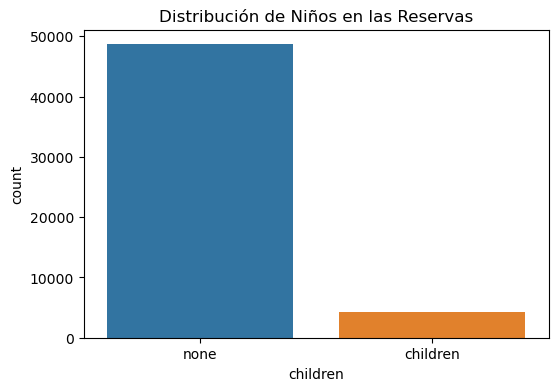

In [83]:
# Distribución de la variable objetivo 'children'
plt.figure(figsize=(6, 4))
sns.countplot(x='children', data=df_entrena)
plt.title('Distribución de Niños en las Reservas')
plt.show()


In [84]:
#veamos la variable objetivo children   

print(df_entrena['children'].value_counts())

none        48647
children     4334
Name: children, dtype: int64


## Variable: hotel

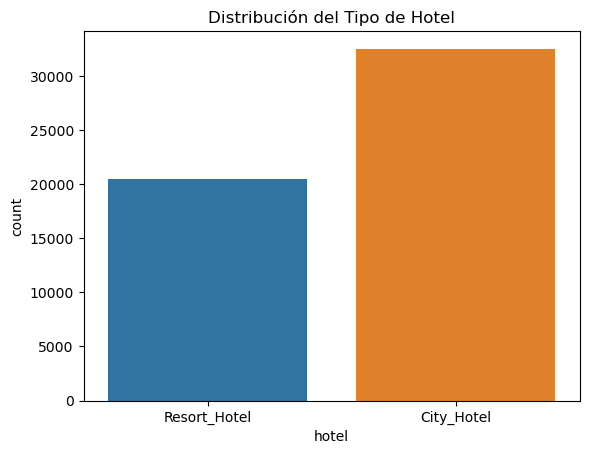

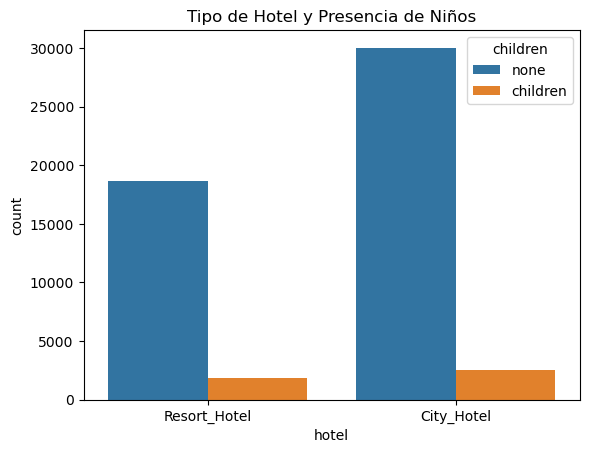

In [85]:
# Distribución del tipo de hotel
sns.countplot(x='hotel', data=df_entrena)
plt.title('Distribución del Tipo de Hotel')
plt.show()

# Relación entre el tipo de hotel y la presencia de niños
sns.countplot(x='hotel', hue='children', data=df_entrena)
plt.title('Tipo de Hotel y Presencia de Niños')
plt.show()



## Variable: lead_time

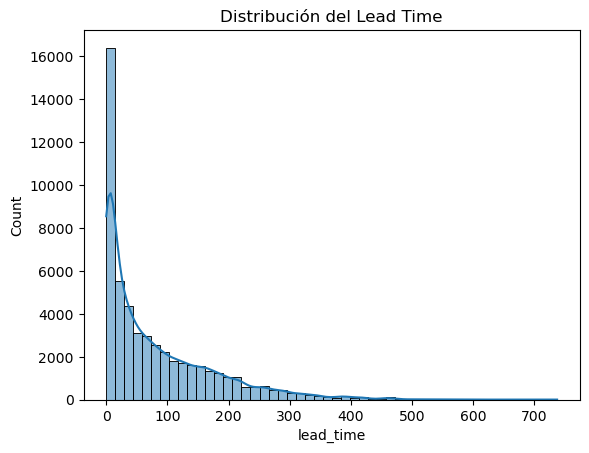

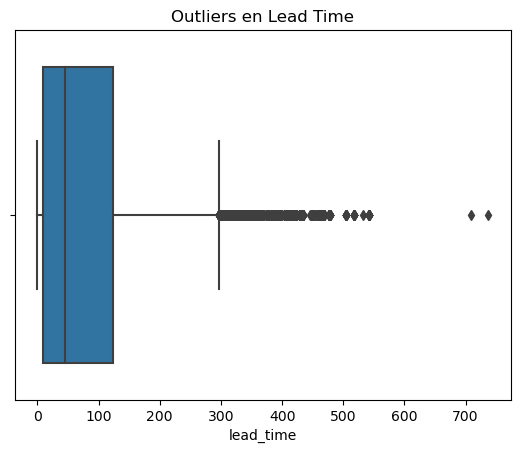

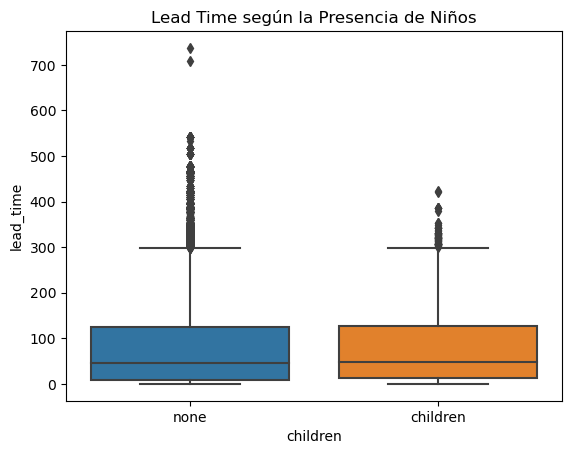

In [86]:
# Distribución del lead time
sns.histplot(df_entrena['lead_time'], bins=50, kde=True)
plt.title('Distribución del Lead Time')
plt.show()

# Boxplot para detectar outliers en lead_time
sns.boxplot(x=df_entrena['lead_time'])
plt.title('Outliers en Lead Time')
plt.show()

# Boxplot de lead_time frente a la presencia de niños
sns.boxplot(x='children', y='lead_time', data=df_entrena)
plt.title('Lead Time según la Presencia de Niños')
plt.show()


## Variable: stays_in_weekend_nights y stays_in_week_nights

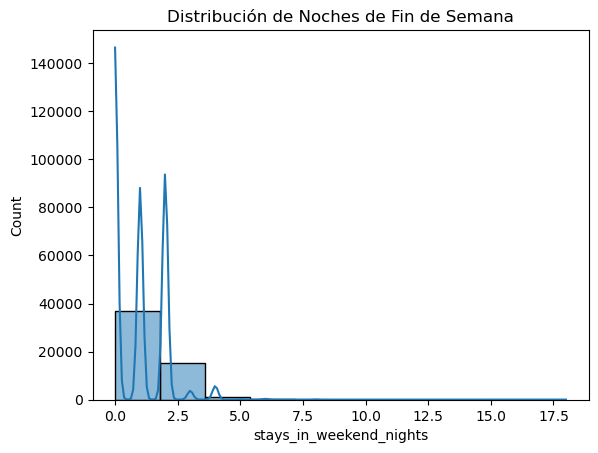

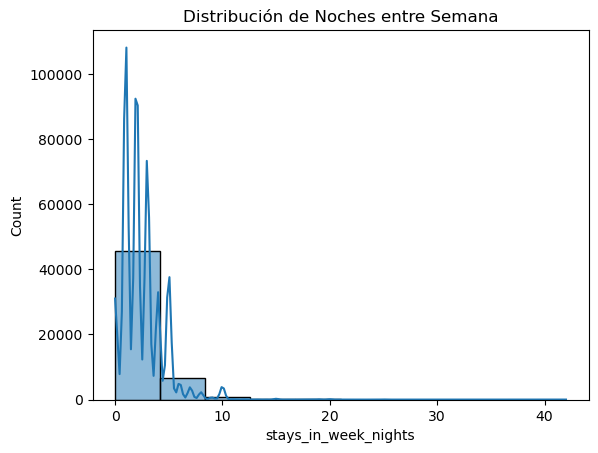

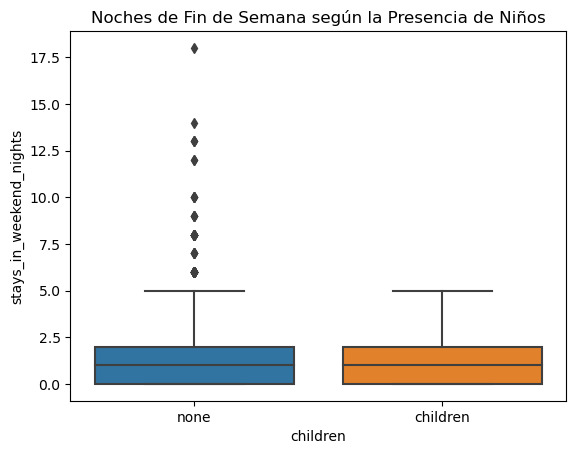

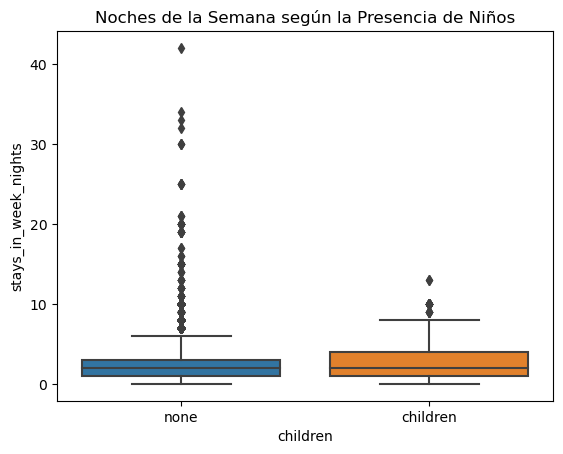

In [87]:
sns.histplot(df_entrena['stays_in_weekend_nights'], bins=10, kde=True)
plt.title('Distribución de Noches de Fin de Semana')
plt.show()

sns.histplot(df_entrena['stays_in_week_nights'], bins=10, kde=True)
plt.title('Distribución de Noches entre Semana')
plt.show()

# Noches de fin de semana según la presencia de niños
sns.boxplot(x='children', y='stays_in_weekend_nights', data=df_entrena)
plt.title('Noches de Fin de Semana según la Presencia de Niños')
plt.show()

# Noches entre semana según la presencia de niños
sns.boxplot(x='children', y='stays_in_week_nights', data=df_entrena)
plt.title('Noches de la Semana según la Presencia de Niños')
plt.show()


## Variable: adults

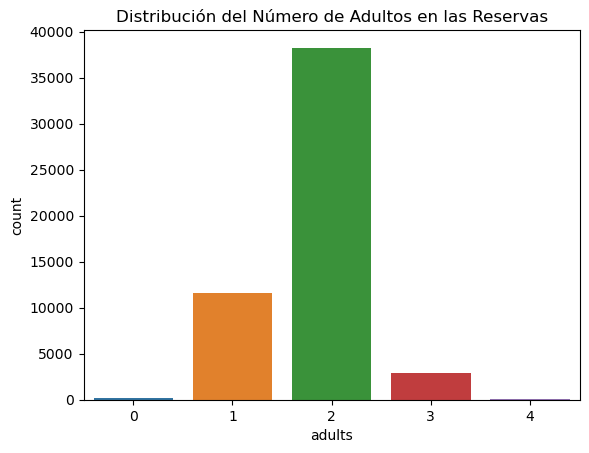

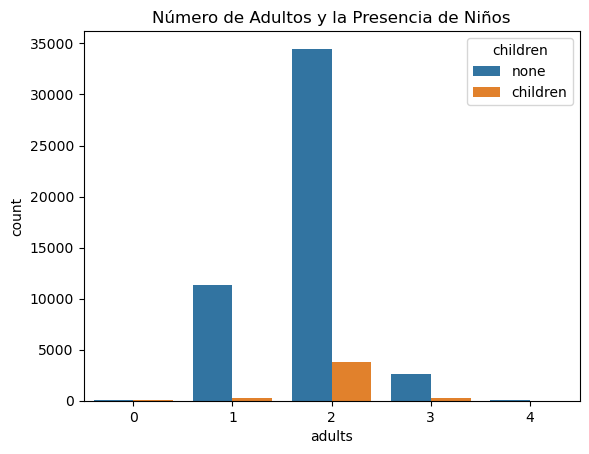

In [88]:
sns.countplot(x='adults', data=df_entrena)
plt.title('Distribución del Número de Adultos en las Reservas')
plt.show()

sns.countplot(x='adults', hue='children', data=df_entrena)
plt.title('Número de Adultos y la Presencia de Niños')
plt.show()


## Variable: meal

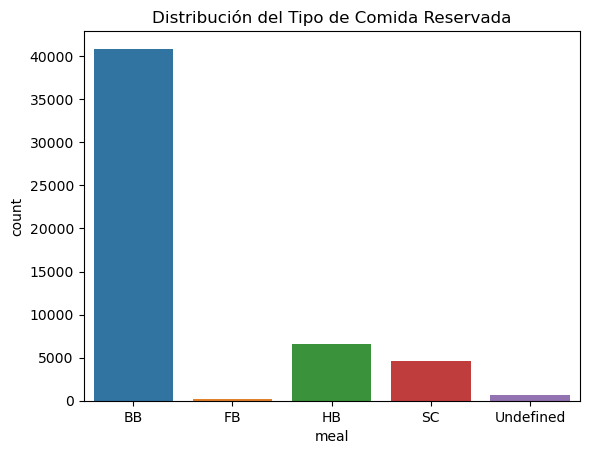

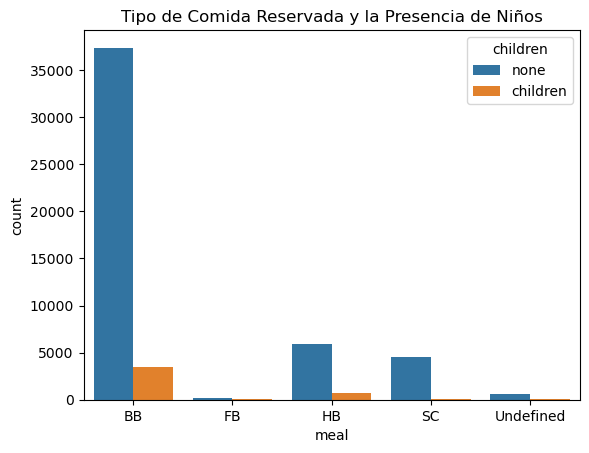

In [89]:
sns.countplot(x='meal', data=df_entrena)
plt.title('Distribución del Tipo de Comida Reservada')
plt.show()

sns.countplot(x='meal', hue='children', data=df_entrena)
plt.title('Tipo de Comida Reservada y la Presencia de Niños')
plt.show()


## Variable: market_segment

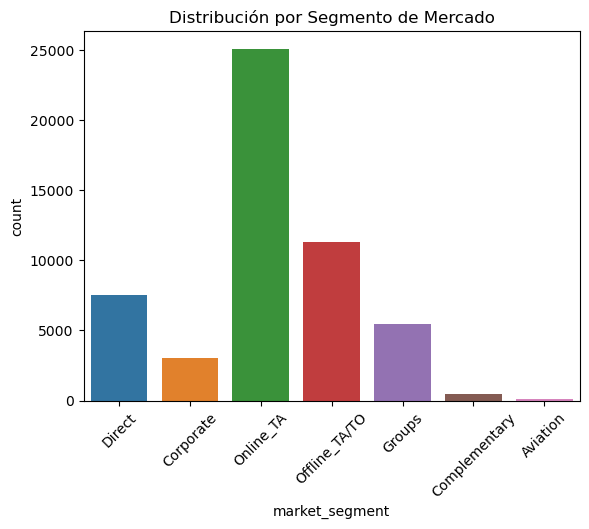

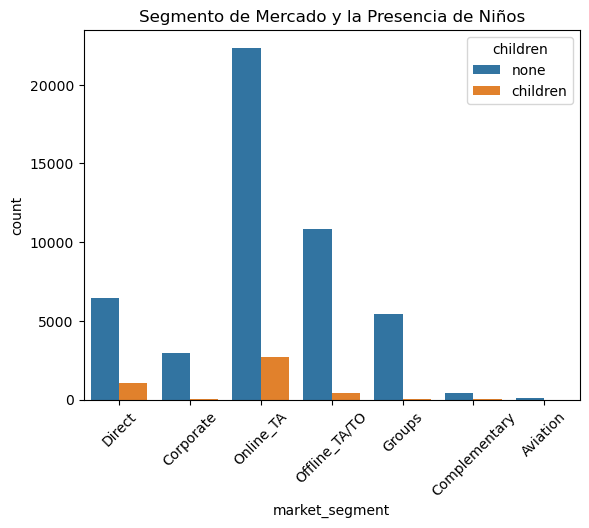

In [90]:
sns.countplot(x='market_segment', data=df_entrena)
plt.title('Distribución por Segmento de Mercado')
plt.xticks(rotation=45)
plt.show()

sns.countplot(x='market_segment', hue='children', data=df_entrena)
plt.title('Segmento de Mercado y la Presencia de Niños')
plt.xticks(rotation=45)
plt.show()



## Variable: distribution_channel

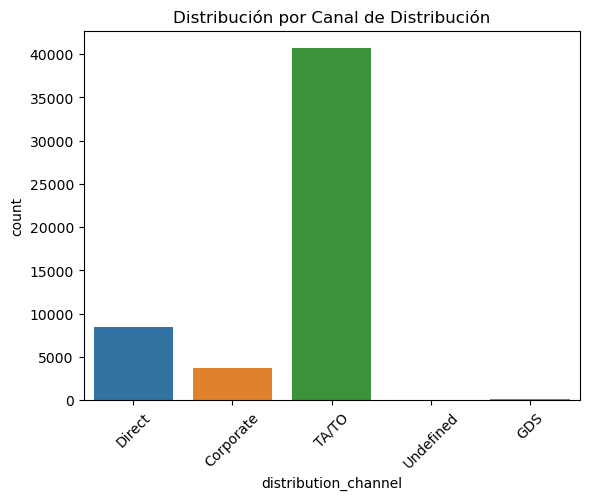

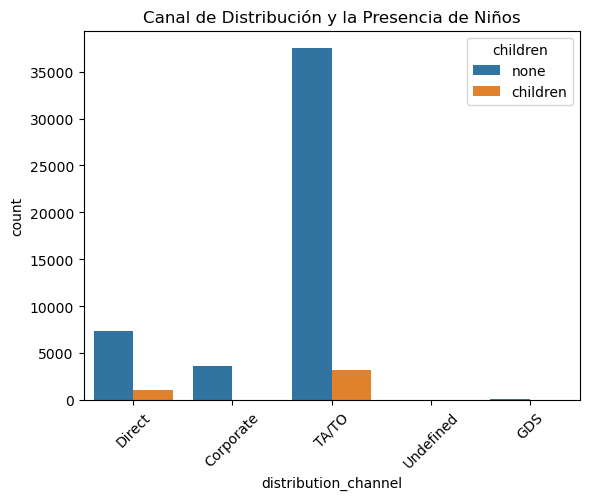

In [91]:
sns.countplot(x='distribution_channel', data=df_entrena)
plt.title('Distribución por Canal de Distribución')
plt.xticks(rotation=45)
plt.show()

sns.countplot(x='distribution_channel', hue='children', data=df_entrena)
plt.title('Canal de Distribución y la Presencia de Niños')
plt.xticks(rotation=45)
plt.show()



## Variable: customer_type

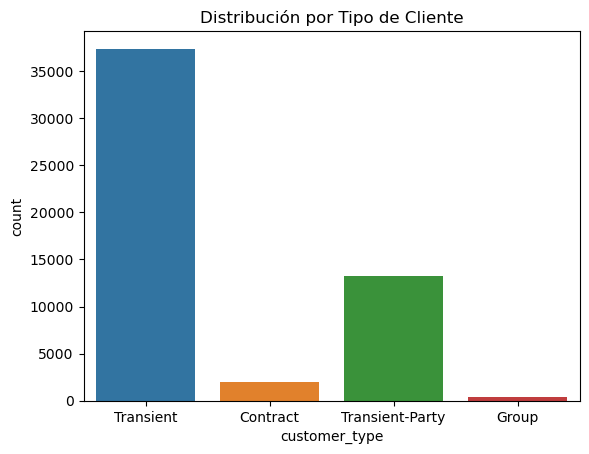

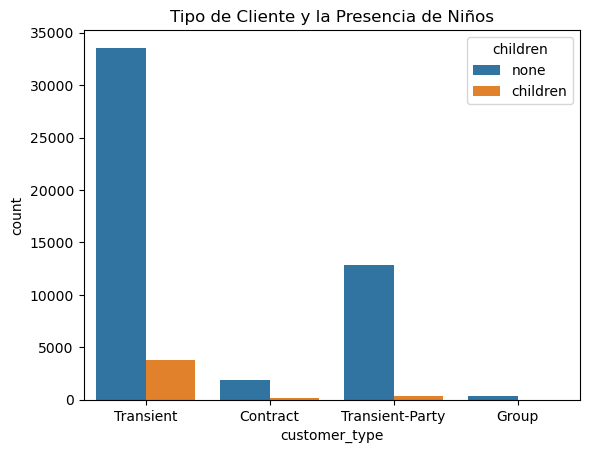

In [92]:
sns.countplot(x='customer_type', data=df_entrena)
plt.title('Distribución por Tipo de Cliente')
plt.show()

sns.countplot(x='customer_type', hue='children', data=df_entrena)
plt.title('Tipo de Cliente y la Presencia de Niños')
plt.show()


## Variable: total_of_special_requests

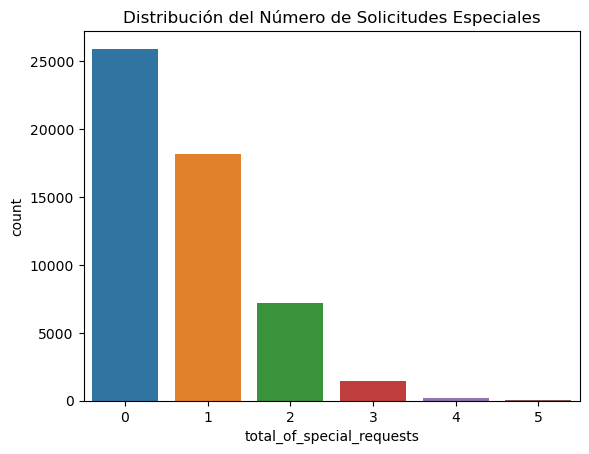

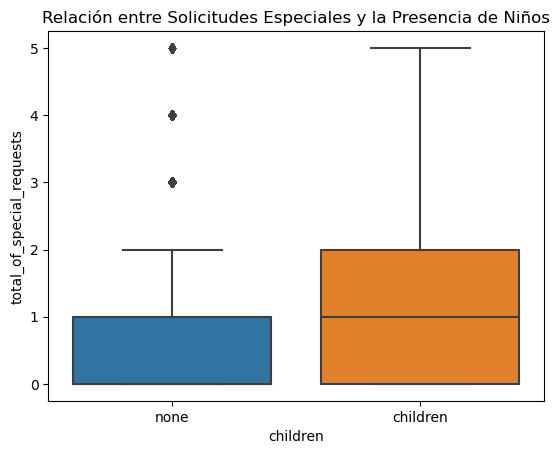

In [93]:
sns.countplot(x='total_of_special_requests', data=df_entrena)
plt.title('Distribución del Número de Solicitudes Especiales')
plt.show()

sns.boxplot(x='children', y='total_of_special_requests', data=df_entrena)
plt.title('Relación entre Solicitudes Especiales y la Presencia de Niños')
plt.show()


## Variable:  days_in_waiting_list

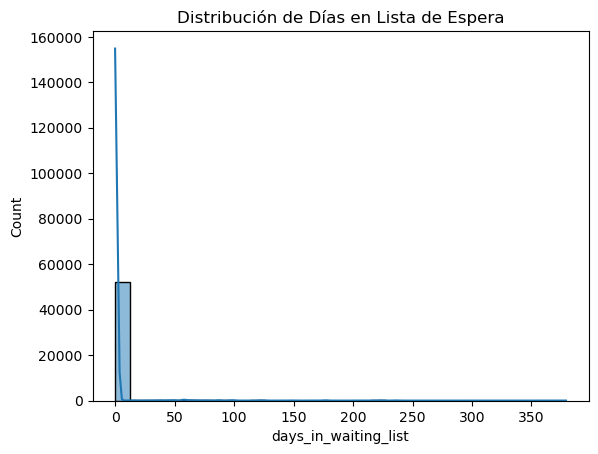

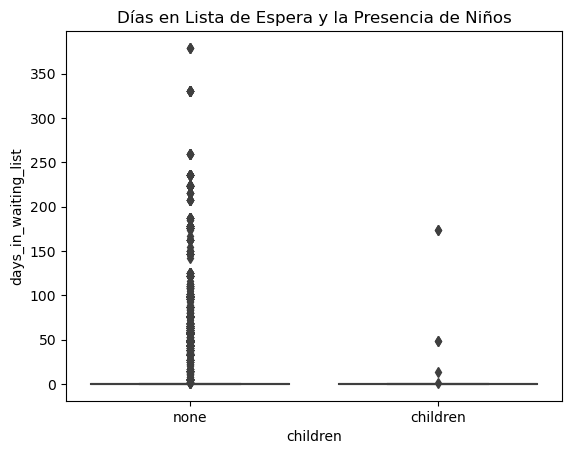

In [94]:

sns.histplot(df_entrena['days_in_waiting_list'], bins=30, kde=True)
plt.title('Distribución de Días en Lista de Espera')
plt.show()

sns.boxplot(x='children', y='days_in_waiting_list', data=df_entrena)
plt.title('Días en Lista de Espera y la Presencia de Niños')
plt.show()


## Variable: previous_bookings_not_canceled

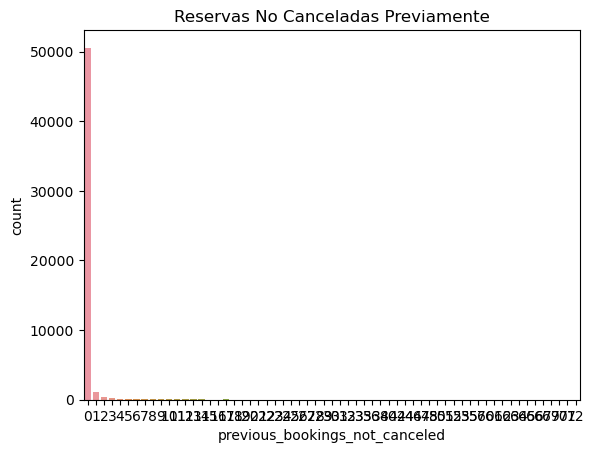

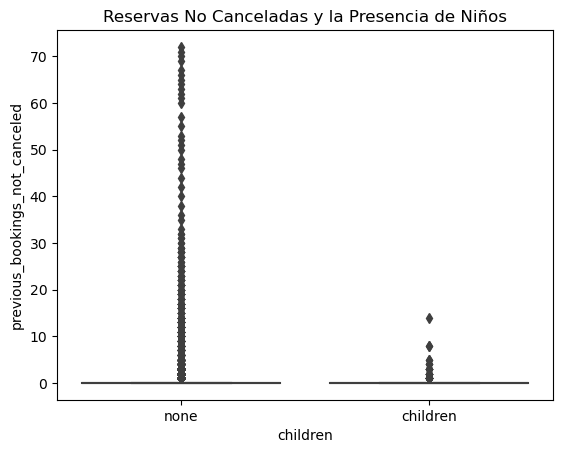

In [95]:
sns.countplot(x='previous_bookings_not_canceled', data=df_entrena)
plt.title('Reservas No Canceladas Previamente')
plt.show()

sns.boxplot(x='children', y='previous_bookings_not_canceled', data=df_entrena)
plt.title('Reservas No Canceladas y la Presencia de Niños')
plt.show()


# Variable: reserved_room_type y assigned_room_type

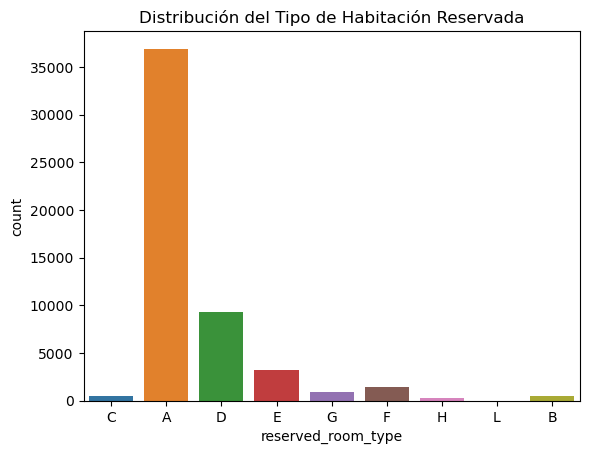

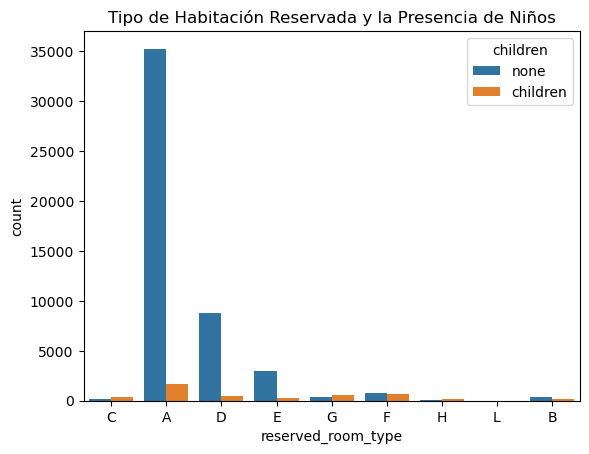

In [96]:
sns.countplot(x='reserved_room_type', data=df_entrena)
plt.title('Distribución del Tipo de Habitación Reservada')
plt.show()

sns.countplot(x='reserved_room_type', hue='children', data=df_entrena)
plt.title('Tipo de Habitación Reservada y la Presencia de Niños')
plt.show()


## Variable: booking_changes

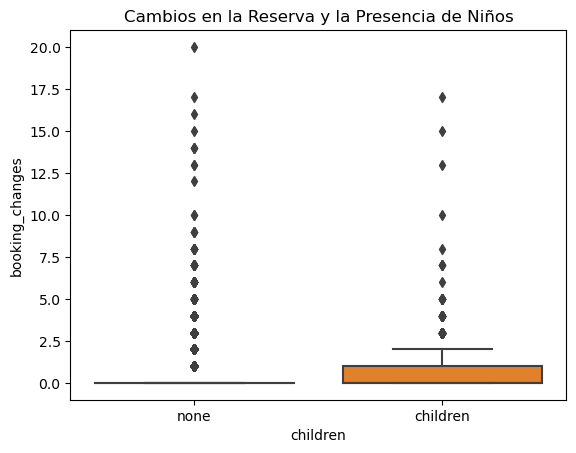

In [97]:
sns.boxplot(x='children', y='booking_changes', data=df_entrena)
plt.title('Cambios en la Reserva y la Presencia de Niños')
plt.show()


In [98]:
print(df_entrena.dtypes)


hotel                              object
lead_time                           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                           object
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             float64
company                           float64
days_in_waiting_list                int64
customer_type                      object
average_daily_rate                float64
required_car_parking_spaces        object
total_of_special_requests         

## Un poco de ingeniería de variables


### Estaciones

In [99]:
# Convertir las fechas en el conjunto de entrenamiento y prueba
df_entrena["arrival_date"] = pd.to_datetime(df_entrena["arrival_date"])
df_prueba["arrival_date"] = pd.to_datetime(df_prueba["arrival_date"])

# Extraer el mes y el día de la semana de la columna de fecha en el conjunto de entrenamiento
df_entrena['arrival_month'] = df_entrena['arrival_date'].dt.month
df_entrena['arrival_dayofweek'] = df_entrena['arrival_date'].dt.dayofweek

# Extraer el mes y el día de la semana de la columna de fecha en el conjunto de prueba
df_prueba['arrival_month'] = df_prueba['arrival_date'].dt.month
df_prueba['arrival_dayofweek'] = df_prueba['arrival_date'].dt.dayofweek

# Función para obtener la estacionalidad según el mes
def get_season(month):
    if month in [12, 1, 2]:
        return 'Invierno'
    elif month in [3, 4, 5]:
        return 'Primavera'
    elif month in [6, 7, 8]:
        return 'Verano'
    else:
        return 'Otoño'

# Aplicar la función de estacionalidad en ambos conjuntos
df_entrena['season'] = df_entrena['arrival_month'].apply(get_season)
df_prueba['season'] = df_prueba['arrival_month'].apply(get_season)

# Convertir la estacionalidad en variables dummy en ambos conjuntos
df_entrena = pd.get_dummies(df_entrena, columns=['season'], drop_first=True)
df_prueba = pd.get_dummies(df_prueba, columns=['season'], drop_first=True)

# Asegurarse de que el conjunto de prueba tenga las mismas columnas que el conjunto de entrenamiento
df_prueba = df_prueba.reindex(columns=df_entrena.columns, fill_value=0)

# Verificar el resultado
print(df_entrena.head())
print(df_prueba.head())



          hotel  lead_time  stays_in_weekend_nights  stays_in_week_nights  \
0  Resort_Hotel        342                        0                     0   
1  Resort_Hotel        737                        0                     0   
2  Resort_Hotel          7                        0                     1   
3  Resort_Hotel         13                        0                     1   
4  Resort_Hotel         14                        0                     2   

   adults children meal country market_segment distribution_channel  ...  \
0       2     none   BB     PRT         Direct               Direct  ...   
1       2     none   BB     PRT         Direct               Direct  ...   
2       1     none   BB     GBR         Direct               Direct  ...   
3       1     none   BB     GBR      Corporate            Corporate  ...   
4       2     none   BB     GBR      Online_TA                TA/TO  ...   

   customer_type  average_daily_rate  required_car_parking_spaces  \
0      Tran

### Variables categóricas


In [100]:
# Seleccionar las columnas categóricas que queremos convertir a variables dummy
categorical_columns = ['hotel', 'meal', 'market_segment', 'distribution_channel', 
                       'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

# Convertir las columnas categóricas en variables dummy en ambos conjuntos (entrenamiento y prueba)
df_entrena = pd.get_dummies(df_entrena, columns=categorical_columns, drop_first=True)
df_prueba = pd.get_dummies(df_prueba, columns=categorical_columns, drop_first=True)

# Asegurarse de que df_prueba tenga las mismas columnas que df_entrena
df_prueba = df_prueba.reindex(columns=df_entrena.columns, fill_value=0)



In [101]:
# Verificar que ambas tablas tengan las mismas columnas y el mismo número de columnas
print(f"Columnas en df_entrena: {df_entrena.shape[1]}")
print(f"Columnas en df_prueba: {df_prueba.shape[1]}")

# Verificar las primeras filas de df_entrena y df_prueba
print(df_entrena.head())
print(df_prueba.head())


Columnas en df_entrena: 59
Columnas en df_prueba: 59
   lead_time  stays_in_weekend_nights  stays_in_week_nights  adults children  \
0        342                        0                     0       2     none   
1        737                        0                     0       2     none   
2          7                        0                     1       1     none   
3         13                        0                     1       1     none   
4         14                        0                     2       2     none   

  country  is_repeated_guest  previous_cancellations  \
0     PRT                  0                       0   
1     PRT                  0                       0   
2     GBR                  0                       0   
3     GBR                  0                       0   
4     GBR                  0                       0   

   previous_bookings_not_canceled  booking_changes  ...  assigned_room_type_F  \
0                               0               

In [102]:
print(df_entrena.dtypes)


lead_time                                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                  object
country                                   object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
booking_changes                            int64
agent                                    float64
company                                  float64
days_in_waiting_list                       int64
average_daily_rate                       float64
required_car_parking_spaces               object
total_of_special_requests                  int64
arrival_date                      datetime64[ns]
arrival_month                              int64
arrival_dayofweek                          int64
season_Otoño                               uint8
season_Primavera    

In [110]:
print(df_entrena.columns.tolist())

['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'country', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'average_daily_rate', 'required_car_parking_spaces', 'total_of_special_requests', 'arrival_date', 'arrival_month', 'arrival_dayofweek', 'season_Otoño', 'season_Primavera', 'season_Verano', 'hotel_Resort_Hotel', 'meal_FB', 'meal_HB', 'meal_SC', 'meal_Undefined', 'market_segment_Complementary', 'market_segment_Corporate', 'market_segment_Direct', 'market_segment_Groups', 'market_segment_Offline_TA/TO', 'market_segment_Online_TA', 'distribution_channel_Direct', 'distribution_channel_GDS', 'distribution_channel_TA/TO', 'distribution_channel_Undefined', 'reserved_room_type_B', 'reserved_room_type_C', 'reserved_room_type_D', 'reserved_room_type_E', 'reserved_room_type_F', 'reserved_room_type_G', 'reserved_room_type_H', 'reserved_room_type_L', 'assigned_r

In [111]:
print(df_prueba.columns.tolist())   

['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'country', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'average_daily_rate', 'required_car_parking_spaces', 'total_of_special_requests', 'arrival_date', 'arrival_month', 'arrival_dayofweek', 'season_Otoño', 'season_Primavera', 'season_Verano', 'hotel_Resort_Hotel', 'meal_FB', 'meal_HB', 'meal_SC', 'meal_Undefined', 'market_segment_Complementary', 'market_segment_Corporate', 'market_segment_Direct', 'market_segment_Groups', 'market_segment_Offline_TA/TO', 'market_segment_Online_TA', 'distribution_channel_Direct', 'distribution_channel_GDS', 'distribution_channel_TA/TO', 'distribution_channel_Undefined', 'reserved_room_type_B', 'reserved_room_type_C', 'reserved_room_type_D', 'reserved_room_type_E', 'reserved_room_type_F', 'reserved_room_type_G', 'reserved_room_type_H', 'reserved_room_type_L', 'assigned_r